# MOR under incompleteness: a two-bin toy study

This notebook isolates a single effect: **how does a threshold-based selection cut bias a naïve fit of a mass–observable relation (MOR), and does a selection-aware likelihood remove that bias?**

Dependency: `numpy` + `scipy` + `matplotlib`. The setup mirrors the physical picture: two disjoint mass bins with intrinsic log-normal scatter, a single observable threshold that preferentially kills the low-mass, low-observable clusters.

## Physical setup

We assume a log-linear MOR
$$\ln \mathrm{Obs} = A + \alpha \, \ln(M / M_\mathrm{piv}) + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma_{\ln})$$

with fiducial $A = 0$, $\alpha = 1.5$, $\sigma_{\ln} = 0.2$, $M_\mathrm{piv} = 3\times 10^{14}\,M_\odot/h$. This form is the standard log-normal MOR used throughout the cluster-cosmology literature ([Lima & Hu 2005](https://arxiv.org/abs/astro-ph/0503363); [Allen, Evrard & Mantz 2011](https://arxiv.org/abs/1103.4829)).

Clusters are drawn in two disjoint bins, uniform in $\log_{10}M$:
- Low: $M \in [5\times 10^{13}, 10^{14}]\,M_\odot/h$
- High: $M \in [5\times 10^{14}, 10^{15}]\,M_\odot/h$

Detection is a single threshold: a cluster survives iff $y = \ln \mathrm{Obs} > y_\mathrm{min}$. Because low-mass clusters have lower mean $y$, a single threshold **automatically** produces higher incompleteness in the low bin — no manual tuning of two separate loss fractions. Real X-ray or SZ surveys behave this way (see e.g. [Vikhlinin et al. 2009](https://arxiv.org/abs/0805.2207); [Mantz et al. 2010](https://arxiv.org/abs/0909.3098)).

## What we test

Two fitting procedures on the *detected* sample:

1. **OLS** — ordinary least squares on $(x_i, y_i)$ with $x = \ln(M/M_\mathrm{piv})$, $y = \ln \mathrm{Obs}$. Estimates $(A, \alpha)$ from the normal equations and $\sigma$ from the residual RMS. **Assumes the sample is a fair draw** — it has no notion of missing points.

2. **Selection-aware MLE** — maximum-likelihood fit of the *truncated* Gaussian likelihood, which explicitly conditions on detection:
$$p(y \mid x, \text{detected}) = \frac{\mathcal{N}(y \mid A + \alpha x, \sigma)}{P(y > y_\mathrm{min} \mid x)}$$
where the denominator is the Gaussian survival function evaluated at the threshold. In the limit $y_\mathrm{min} \to -\infty$, this reduces to OLS.

We scan $y_\mathrm{min}$ over a grid, run many mock realisations at each threshold, and plot the fitted $(\sigma, \alpha, A)$ vs the resulting total incompleteness $f_\mathrm{total}$.

## References
- **Kelly 2007** ([arXiv:0705.2774](https://arxiv.org/abs/0705.2774)) — definitive treatment of regression with selection + measurement error in astronomy. §5 covers truncation explicitly. The paper behind `linmix`.
- **Hogg, Bovy & Lang 2010** ([arXiv:1008.4686](https://arxiv.org/abs/1008.4686)) — §7 is the friendliest short intro to selection effects in fitting.
- **Lima & Hu 2005** ([arXiv:astro-ph/0503363](https://arxiv.org/abs/astro-ph/0503363)) — self-calibration of the observable–mass distribution in cluster counts.
- **Stanek et al. 2006** ([arXiv:astro-ph/0602324](https://arxiv.org/abs/astro-ph/0602324)) — worked example of scatter measurement under flux-limited selection.
- **Grandis, Mohr, Dietrich et al. 2019** ([arXiv:1902.11265](https://arxiv.org/abs/1902.11265)) — selection-induced biases in the eROSITA context (closest paper to your project).
- **Mantz 2019** ([arXiv:1902.06791](https://arxiv.org/abs/1902.06791)) — generalised selection-aware method for cluster scaling relations.
- **Sereno & Ettori 2015 (CoMaLit-I)** ([arXiv:1502.05413](https://arxiv.org/abs/1502.05413)) — Bayesian treatment of scaling relations under truncation.
- **Isobe, Feigelson, Akritas & Babu 1990** (ApJ 364, 104; [ADS](https://ui.adsabs.harvard.edu/abs/1990ApJ...364..104I)) — the classic "which regression?" paper on OLS variants in astronomy.


## 1 — Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

# ---- Fiducial MOR parameters ----
A_TRUE     = 0.0            # intercept (choice of Obs units)
ALPHA_TRUE = 1.5            # slope
SIGMA_TRUE = 0.2            # intrinsic scatter in ln(Obs)
M_PIV      = 3e14           # pivot mass, M_sun/h

# ---- Mass bins (disjoint) ----
M_EDGES_LOW  = (5e13, 1e14)
M_EDGES_HIGH = (5e14, 1e15)

# ---- Sample size per bin ----
N_LOW  = 100
N_HIGH = 50

# Master RNG (a fresh RNG is used for each realisation inside the scan so
# results are reproducible per (threshold, realisation) index)
rng_master = np.random.default_rng(42)


## 2 — Mock cluster catalogue

Draw $N_\mathrm{low}$ + $N_\mathrm{high}$ clusters uniformly in $\log_{10} M$ within each bin, then compute $\ln \mathrm{Obs}$ from the MOR with intrinsic log-normal scatter. Returns arrays in the fit variables $x = \ln(M/M_\mathrm{piv})$ and $y = \ln \mathrm{Obs}$, plus a bin label (0 = low, 1 = high) for bookkeeping.

*Design note.* Uniform in $\log_{10} M$ within each bin is a deliberate simplification: real halos follow the mass function, so the low edge of each bin is more populated than the high edge. Swapping in HMF-weighted sampling would make the low-mass bin's centroid slightly lower and would amplify the biases below, but doesn't change the qualitative story. Left as an easy extension.

In [3]:
def generate_mock(N_low, N_high, M_edges_low, M_edges_high, rng):
    logM_low  = rng.uniform(np.log10(M_edges_low[0]),  np.log10(M_edges_low[1]),  N_low)
    logM_high = rng.uniform(np.log10(M_edges_high[0]), np.log10(M_edges_high[1]), N_high)
    logM = np.concatenate([logM_low, logM_high])
    M = 10 ** logM
    x = np.log(M / M_PIV)
    y_mean = A_TRUE + ALPHA_TRUE * x
    y = y_mean + rng.normal(0.0, SIGMA_TRUE, size=len(x))
    bin_label = np.concatenate([np.zeros(N_low, dtype=int),
                                np.ones(N_high, dtype=int)])
    return M, x, y, bin_label


## 3 — Two fits

### 3.1 OLS

Closed-form linear regression: minimise $\sum_i (y_i - A - \alpha x_i)^2$, then estimate $\sigma$ from the residual RMS with $N-2$ degrees of freedom (unbiased under Gaussian errors, *no truncation*).

### 3.2 Selection-aware MLE

Negative log-likelihood of the truncated Gaussian, minimised with Nelder–Mead. We parametrise as $(A, \alpha, \ln\sigma)$ so the sampler stays in unbounded space and $\sigma > 0$ is automatic.

$$-\ln \mathcal{L}(A, \alpha, \sigma) = -\sum_i \left[ \ln \phi\!\left(\frac{y_i - A - \alpha x_i}{\sigma}\right) - \ln \sigma - \ln P(y > y_\mathrm{min} \mid x_i) \right]$$

with $\phi$ the standard normal PDF and $P(y > y_\mathrm{min} \mid x_i) = 1 - \Phi\!\left((y_\mathrm{min} - A - \alpha x_i)/\sigma\right)$. This is exactly the structure of the migration matrix in your `scatter_massde.py`, just applied to individual points rather than binned counts.

In [4]:
def fit_ols(x, y):
    """Ordinary least squares; sigma from residual RMS with N-2 dof."""
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    alpha_hat, A_hat = np.polyfit(x, y, 1)   # returns [slope, intercept]
    resid = y - (A_hat + alpha_hat * x)
    sigma_hat = np.std(resid, ddof=2)
    return A_hat, alpha_hat, sigma_hat


def neg_loglike_truncated(params, x, y, y_min):
    """Negative log-likelihood of the truncated-Gaussian MOR."""
    A, alpha, log_sigma = params
    sigma = np.exp(log_sigma)
    mu = A + alpha * x
    log_pdf  = norm.logpdf(y, loc=mu, scale=sigma)
    log_surv = norm.logsf(y_min, loc=mu, scale=sigma)  # ln P(y > y_min | x)
    return -np.sum(log_pdf - log_surv)


def fit_selection_aware(x, y, y_min, init=(0.0, 1.5, 0.2)):
    """MLE of the truncated Gaussian likelihood. `init` = (A, alpha, sigma)."""
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    x0 = [init[0], init[1], np.log(init[2])]
    result = minimize(
        neg_loglike_truncated, x0=x0, args=(x, y, y_min),
        method='Nelder-Mead',
        options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 10000},
    )
    if not result.success:
        return np.nan, np.nan, np.nan
    A, alpha, log_sigma = result.x
    return A, alpha, np.exp(log_sigma)


## 4 — Sanity check: no selection

Both fits should recover truth when $y_\mathrm{min}$ is far below any data. This validates the machinery before we do anything interesting.

In [5]:
M, x, y, bin_lab = generate_mock(1000, 1000, M_EDGES_LOW, M_EDGES_HIGH, rng_master)
y_min_none = -1e6   # effectively no cut

Ao, ao, so = fit_ols(x, y)
As, as_, ss = fit_selection_aware(x, y, y_min_none, init=(A_TRUE, ALPHA_TRUE, SIGMA_TRUE))

print(f"Truth              A={A_TRUE:+.3f}  alpha={ALPHA_TRUE:.3f}  sigma={SIGMA_TRUE:.3f}")
print(f"OLS                A={Ao:+.3f}  alpha={ao:.3f}  sigma={so:.3f}")
print(f"Selection-aware    A={As:+.3f}  alpha={as_:.3f}  sigma={ss:.3f}")


Truth              A=+0.000  alpha=1.500  sigma=0.200
OLS                A=+0.004  alpha=1.500  sigma=0.199
Selection-aware    A=+0.004  alpha=1.500  sigma=0.199


## 5 — Diagnostic

One realisation at a threshold that removes a substantial fraction of the low bin. Detected points in **black**, lost points in **red**, three fit lines overlaid: **gold** truth, **navy** OLS on detected only (naïve), **green dashed** selection-aware on detected only.

**What to look for.** The gold truth line should pass through the centroid of the *combined* black + red cloud (i.e. it's the correct mean at each $M$). The navy OLS line is fit only to the black points; its low-mass end will pull upward and its slope will pivot **shallower** than truth. The green dashed selection-aware line, using the same black points but the *correct* truncated likelihood, should sit essentially on top of gold.

*Note on the direction of slope bias.* Your sketch shows the "Incomplete" fit **steeper** than "Full". That geometry arises when selection is applied *within* a narrow mass range so surviving points pivot around their own centroid. With our disjoint two-bin setup, the high-mass bin is essentially untouched by the cut and acts as an anchor, so the pivot goes the *other* way: OLS becomes **shallower**. The magnitude of the bias is the same either way; only the sign flips depending on the geometry.

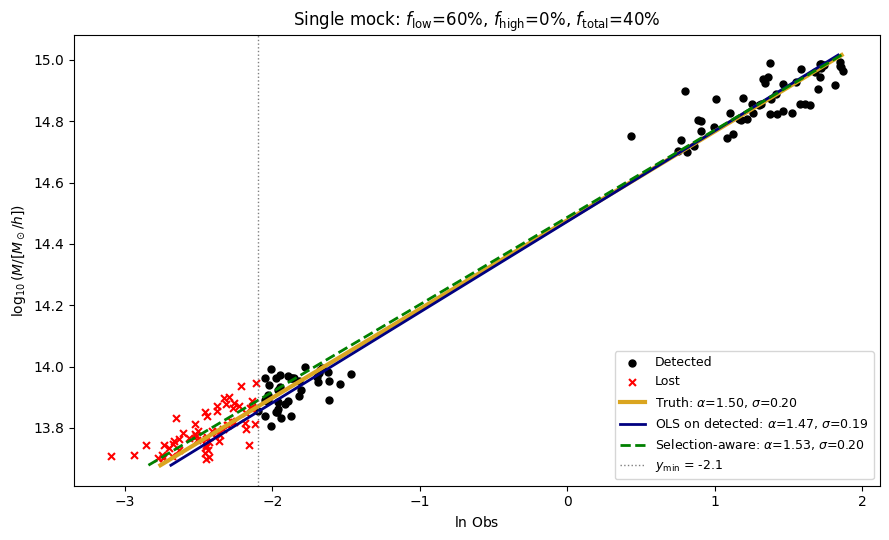

In [6]:
# Reproduce the sketch: one realisation, threshold tuned to ~25-30% total loss.
rng_demo = np.random.default_rng(7)
M, x, y, bin_lab = generate_mock(N_LOW, N_HIGH, M_EDGES_LOW, M_EDGES_HIGH, rng_demo)

Y_MIN_DEMO = -2.1     # roughly f_total ~ 25%
detected = y > Y_MIN_DEMO

Ao, ao, so = fit_ols(x[detected], y[detected])
As, as_, ss = fit_selection_aware(
    x[detected], y[detected], Y_MIN_DEMO,
    init=(A_TRUE, ALPHA_TRUE, SIGMA_TRUE),
)

fig, ax = plt.subplots(figsize=(9, 5.5))
# Swapped axes: ln(Obs) on x, log10(M) on y
ax.scatter(y[detected],  np.log10(M[detected]),  c='black', s=25, label='Detected')
ax.scatter(y[~detected], np.log10(M[~detected]), c='red',   s=25, marker='x', label='Lost')

x_grid = np.linspace(x.min() - 0.05, x.max() + 0.05, 100)
logM_grid = np.log10(M_PIV * np.exp(x_grid))
ax.plot(A_TRUE + ALPHA_TRUE * x_grid, logM_grid,
        color='goldenrod', lw=3, label=fr'Truth: $\alpha$={ALPHA_TRUE:.2f}, $\sigma$={SIGMA_TRUE:.2f}')
ax.plot(Ao + ao * x_grid, logM_grid,
        color='navy', lw=2, label=fr'OLS on detected: $\alpha$={ao:.2f}, $\sigma$={so:.2f}')
ax.plot(As + as_ * x_grid, logM_grid,
        color='green', ls='--', lw=2,
        label=fr'Selection-aware: $\alpha$={as_:.2f}, $\sigma$={ss:.2f}')
# Threshold is now a VERTICAL line at y_min
ax.axvline(Y_MIN_DEMO, color='gray', ls=':', lw=1, label=fr'$y_{{\min}}$ = {Y_MIN_DEMO}')

f_low  = 1 - detected[bin_lab==0].mean()
f_high = 1 - detected[bin_lab==1].mean()
f_tot  = 1 - detected.mean()
ax.set_title(fr'Single mock: $f_\mathrm{{low}}$={f_low:.0%}, $f_\mathrm{{high}}$={f_high:.0%}, $f_\mathrm{{total}}$={f_tot:.0%}')
ax.set_xlabel(r'$\ln\,\mathrm{Obs}$')
ax.set_ylabel(r'$\log_{10}(M / [M_\odot / h])$')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 6 — The scan

At each threshold value we draw `n_realizations` fresh mocks, apply the threshold, and run **both** fits on the surviving points. We store $(A_\mathrm{fit}, \alpha_\mathrm{fit}, \sigma_\mathrm{fit})$ and the per-bin incompletenesses for each mock.

The realisation-to-realisation spread at fixed $y_\mathrm{min}$ is our error band on the scan curves. It's a *frequentist* uncertainty — "how much does the point estimate wobble under repeated experiments?" — which is the right question for characterising a fitting procedure. (Bayesian posterior width from a single mock would answer a different question; see the earlier discussion.)

In [7]:
def scan(y_min_grid, n_realizations, N_low, N_high,
         M_edges_low, M_edges_high,
         seed_offset=0, min_detected=10):
    n_ym = len(y_min_grid)
    keys = ['f_low', 'f_high', 'f_total',
            'A_ols', 'alpha_ols', 'sigma_ols',
            'A_sel', 'alpha_sel', 'sigma_sel']
    results = {k: np.full((n_ym, n_realizations), np.nan) for k in keys}

    for i, y_min in enumerate(y_min_grid):
        for j in range(n_realizations):
            rng = np.random.default_rng(seed_offset + i * 1000 + j)
            M, x, y, bin_lab = generate_mock(N_low, N_high,
                                             M_edges_low, M_edges_high, rng)
            detected = y > y_min

            results['f_low'  ][i, j] = 1 - detected[bin_lab == 0].mean()
            results['f_high' ][i, j] = 1 - detected[bin_lab == 1].mean()
            results['f_total'][i, j] = 1 - detected.mean()

            if detected.sum() < min_detected:
                continue
            xd, yd = x[detected], y[detected]

            Ao, ao, so   = fit_ols(xd, yd)
            As, as_, ss  = fit_selection_aware(
                xd, yd, y_min, init=(A_TRUE, ALPHA_TRUE, SIGMA_TRUE))

            results['A_ols'    ][i, j] = Ao
            results['alpha_ols'][i, j] = ao
            results['sigma_ols'][i, j] = so
            results['A_sel'    ][i, j] = As
            results['alpha_sel'][i, j] = as_
            results['sigma_sel'][i, j] = ss

    return results


Y_MIN_GRID     = np.linspace(-3.5, -1.0, 12)
N_REALIZATIONS = 100

results = scan(Y_MIN_GRID, N_REALIZATIONS,
               N_LOW, N_HIGH,
               M_EDGES_LOW, M_EDGES_HIGH,
               seed_offset=1000)
print(f"Scan complete: {len(Y_MIN_GRID)} thresholds x {N_REALIZATIONS} realisations.")


Scan complete: 12 thresholds x 100 realisations.


## 7 — Incompleteness table

For each threshold, the mean of $f_\mathrm{low}$, $f_\mathrm{high}$, and $f_\mathrm{total}$ across realisations. Note that $f_\mathrm{high}$ stays essentially at 0 across most of the scan — the wide gap between the bins means a threshold that cuts the low bin is nowhere near the high bin. This is the physically realistic behaviour of a flux-limited survey: it primarily loses the faintest low-mass clusters, and the high-mass end is anchored.

In [8]:
def summary(arr):
    """mean, 16th, 84th percentiles across realisations for each threshold row."""
    return (np.nanmean(arr, axis=1),
            np.nanpercentile(arr, 16, axis=1),
            np.nanpercentile(arr, 84, axis=1))

f_low_m,  _, _ = summary(results['f_low'])
f_high_m, _, _ = summary(results['f_high'])
f_tot_m,  _, _ = summary(results['f_total'])

print(f"{'y_min':>7} {'f_low':>9} {'f_high':>9} {'f_total':>9}")
for ym, fl, fh, ft in zip(Y_MIN_GRID, f_low_m, f_high_m, f_tot_m):
    print(f"{ym:7.2f} {fl:9.1%} {fh:9.1%} {ft:9.1%}")


  y_min     f_low    f_high   f_total
  -3.50      0.0%      0.0%      0.0%
  -3.27      0.0%      0.0%      0.0%
  -3.05      0.3%      0.0%      0.2%
  -2.82      3.1%      0.0%      2.1%
  -2.59     13.3%      0.0%      8.9%
  -2.36     30.9%      0.0%     20.6%
  -2.14     52.9%      0.0%     35.3%
  -1.91     74.2%      0.0%     49.5%
  -1.68     90.3%      0.0%     60.2%
  -1.45     98.2%      0.0%     65.5%
  -1.23     99.9%      0.0%     66.6%
  -1.00    100.0%      0.0%     66.7%


## 8 — Main result: $\sigma$ vs $f_\mathrm{total}$

The plot you asked for. Truth as horizontal reference; OLS in navy, selection-aware in green; shaded bands are the 16–84th percentile across realisations at each threshold.

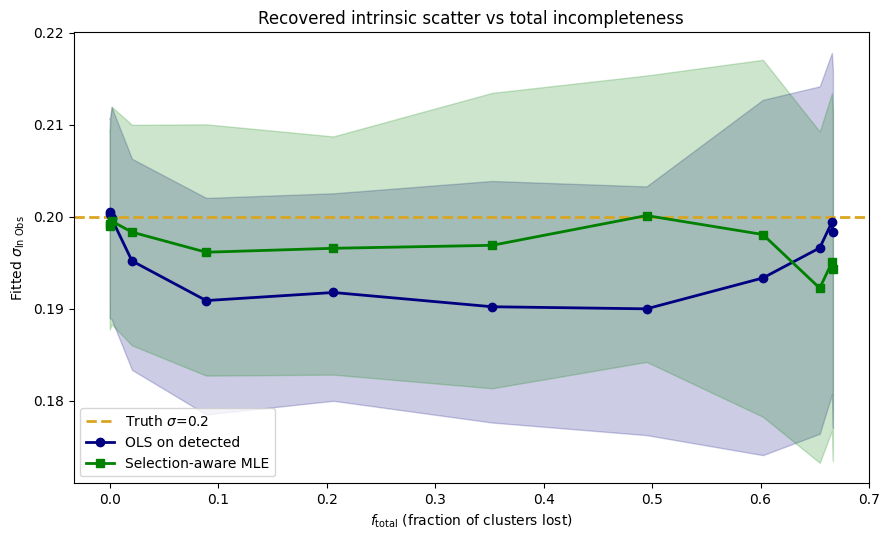

In [9]:
s_o_m, s_o_lo, s_o_hi = summary(results['sigma_ols'])
s_s_m, s_s_lo, s_s_hi = summary(results['sigma_sel'])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axhline(SIGMA_TRUE, color='goldenrod', ls='--', lw=2,
           label=fr'Truth $\sigma$={SIGMA_TRUE}')

ax.plot(f_tot_m, s_o_m, 'o-', color='navy', lw=2, label='OLS on detected')
ax.fill_between(f_tot_m, s_o_lo, s_o_hi, color='navy', alpha=0.2)

ax.plot(f_tot_m, s_s_m, 's-', color='green', lw=2, label='Selection-aware MLE')
ax.fill_between(f_tot_m, s_s_lo, s_s_hi, color='green', alpha=0.2)

ax.set_xlabel(r'$f_\mathrm{total}$ (fraction of clusters lost)')
ax.set_ylabel(r'Fitted $\sigma_{\ln\,\mathrm{Obs}}$')
ax.set_title('Recovered intrinsic scatter vs total incompleteness')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## 9 — Companion panels: $\alpha$ and $A$ vs $f_\mathrm{total}$

In this two-bin geometry, the **slope** and **intercept** are the more visibly biased quantities — the wide mass lever arm gives the naïve fit a lot of room to pivot. This is a useful teaching point: $\sigma$ isn't necessarily the most sensitive diagnostic of selection bias in scaling relations; the mean relation itself is.

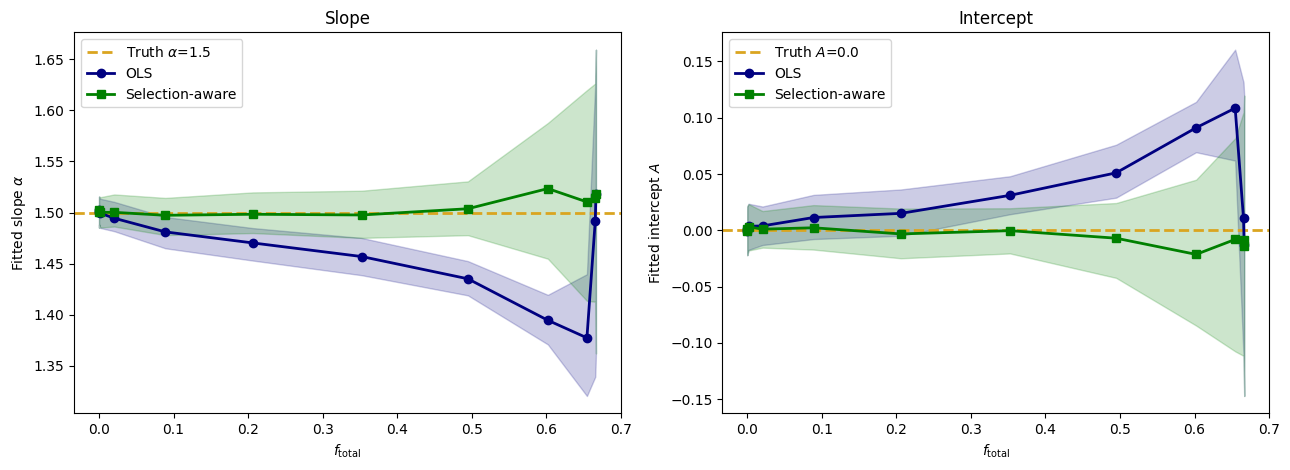

In [10]:
a_o_m, a_o_lo, a_o_hi = summary(results['alpha_ols'])
a_s_m, a_s_lo, a_s_hi = summary(results['alpha_sel'])
A_o_m, A_o_lo, A_o_hi = summary(results['A_ols'])
A_s_m, A_s_lo, A_s_hi = summary(results['A_sel'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ax1.axhline(ALPHA_TRUE, color='goldenrod', ls='--', lw=2, label=fr'Truth $\alpha$={ALPHA_TRUE}')
ax1.plot(f_tot_m, a_o_m, 'o-', color='navy', lw=2, label='OLS')
ax1.fill_between(f_tot_m, a_o_lo, a_o_hi, color='navy', alpha=0.2)
ax1.plot(f_tot_m, a_s_m, 's-', color='green', lw=2, label='Selection-aware')
ax1.fill_between(f_tot_m, a_s_lo, a_s_hi, color='green', alpha=0.2)
ax1.set_xlabel(r'$f_\mathrm{total}$')
ax1.set_ylabel(r'Fitted slope $\alpha$')
ax1.set_title('Slope')
ax1.legend()

ax2.axhline(A_TRUE, color='goldenrod', ls='--', lw=2, label=fr'Truth $A$={A_TRUE}')
ax2.plot(f_tot_m, A_o_m, 'o-', color='navy', lw=2, label='OLS')
ax2.fill_between(f_tot_m, A_o_lo, A_o_hi, color='navy', alpha=0.2)
ax2.plot(f_tot_m, A_s_m, 's-', color='green', lw=2, label='Selection-aware')
ax2.fill_between(f_tot_m, A_s_lo, A_s_hi, color='green', alpha=0.2)
ax2.set_xlabel(r'$f_\mathrm{total}$')
ax2.set_ylabel(r'Fitted intercept $A$')
ax2.set_title('Intercept')
ax2.legend()

plt.tight_layout()
plt.show()


## 10 — Alternative selection: bin-wise fraction loss

The threshold-based selection above is what a real flux-limited survey approximates. But it has a limitation for our study: with a wide bin gap, a single $y_\mathrm{min}$ that meaningfully affects the low bin barely touches the high bin (the $f_\mathrm{high}$ column stayed at 0% throughout). We never got to see what happens when *both* bins lose clusters simultaneously.

The fraction-based alternative: within each bin, remove the lowest-observable fraction $f_\mathrm{low}$ (low bin) and $f_\mathrm{high}$ (high bin). This is *rank-based* selection: sort by $y$, cut the bottom $f$. In real analyses, this would correspond to knowing your completeness function well enough to say "we're 80% complete in this bin, 90% in that bin" — which happens after an injection–recovery calibration exercise.

**Default ratio.** From our earlier discussion: $f_\mathrm{low} : f_\mathrm{high} = 2 : 1$, so at each scan point $f_\mathrm{high} = f_\mathrm{low}/2$. This encodes the expectation that lower-mass, fainter clusters are always harder to detect. We scan $f_\mathrm{low} \in [0, 0.5]$, giving $f_\mathrm{total} \in [0, 37.5\%]$ (weighted average with equal $N$ per bin).

**Selection-aware fit under fraction selection.** Fraction selection is equivalent to a *bin-dependent* threshold: within bin $k$, the effective $y_\mathrm{min}^{(k)}$ is the observable value of the lowest-$y$ surviving cluster in that bin. So the truncated-Gaussian likelihood generalises to
$$-\ln \mathcal{L}(A, \alpha, \sigma) = -\sum_i \left[ \ln \phi\!\left(\tfrac{y_i - A - \alpha x_i}{\sigma}\right) - \ln \sigma - \ln P(y > y_\mathrm{min}^{(k_i)} \mid x_i) \right]$$

where $k_i$ is the bin of point $i$. We just pass a *per-point* $y_\mathrm{min}$ array to `norm.logsf`.

*Caveat.* Using the empirical $y_\mathrm{min}$ from the same mock as the fit is slightly circular — in a real analysis you'd measure completeness from external injection tests, not from the sample itself. For the pedagogy here it's fine; the answer converges to the "true" bin-dependent threshold as $N$ grows.


In [11]:
def fraction_based_selection(y, bin_lab, f_low, f_high):
    """Remove the lowest-y f_low fraction from bin 0, f_high from bin 1.

    Returns:
        detected : bool array of survivors
        (y_min_low, y_min_high) : empirical thresholds per bin (=y of lowest survivor)
    """
    detected = np.ones(len(y), dtype=bool)
    y_min_per_bin = [-np.inf, -np.inf]

    for k, f in [(0, f_low), (1, f_high)]:
        idx = np.where(bin_lab == k)[0]
        if len(idx) == 0 or f <= 0:
            continue
        n_remove = int(round(f * len(idx)))
        if n_remove == 0:
            continue
        if n_remove >= len(idx):
            detected[idx] = False
            continue
        order = np.argsort(y[idx])
        detected[idx[order[:n_remove]]] = False
        y_min_per_bin[k] = y[idx[order[n_remove:]]].min()

    return detected, tuple(y_min_per_bin)


def neg_loglike_truncated_perpoint(params, x, y, y_min_arr):
    """Truncated-Gaussian negative log-likelihood with a per-point y_min."""
    A, alpha, log_sigma = params
    sigma = np.exp(log_sigma)
    mu = A + alpha * x
    log_pdf  = norm.logpdf(y, loc=mu, scale=sigma)
    log_surv = norm.logsf(y_min_arr, loc=mu, scale=sigma)
    return -np.sum(log_pdf - log_surv)


def fit_selection_aware_perpoint(x, y, y_min_arr, init=(0.0, 1.5, 0.2)):
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    x0 = [init[0], init[1], np.log(init[2])]
    r = minimize(
        neg_loglike_truncated_perpoint, x0=x0, args=(x, y, y_min_arr),
        method='Nelder-Mead',
        options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 10000},
    )
    if not r.success:
        return np.nan, np.nan, np.nan
    A, alpha, log_sigma = r.x
    return A, alpha, np.exp(log_sigma)


### Diagnostic: single mock under fraction-based selection

One realisation at $(f_\mathrm{low}, f_\mathrm{high}) = (30\%, 15\%)$. Both bins now lose their faintest clusters, and both bin centroids get pulled up (unlike the threshold case, where only the low bin was affected). What to look for: the OLS line's *intercept* is more strongly biased than its slope here, because both bins pivot upward together.

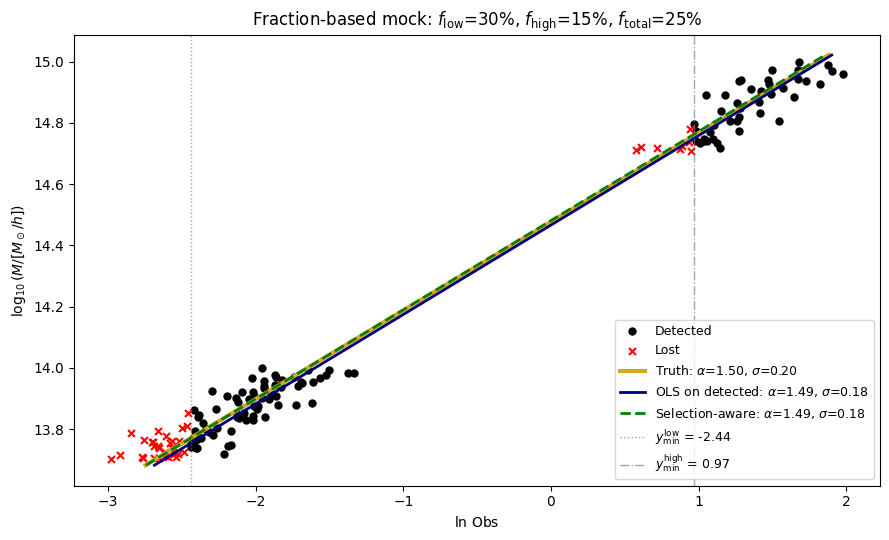

In [17]:
rng_demo2 = np.random.default_rng(11)
M, x, y, bin_lab = generate_mock(N_LOW, N_HIGH, M_EDGES_LOW, M_EDGES_HIGH, rng_demo2)

F_LOW_DEMO  = 0.30
F_HIGH_DEMO = 0.15
detected, (ym_lo, ym_hi) = fraction_based_selection(y, bin_lab, F_LOW_DEMO, F_HIGH_DEMO)

Ao, ao, so = fit_ols(x[detected], y[detected])
y_min_arr = np.where(bin_lab[detected] == 0, ym_lo, ym_hi)
As, as_, ss = fit_selection_aware_perpoint(
    x[detected], y[detected], y_min_arr,
    init=(A_TRUE, ALPHA_TRUE, SIGMA_TRUE),
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(y[detected],  np.log10(M[detected]),  c='black', s=25, label='Detected')
ax.scatter(y[~detected], np.log10(M[~detected]), c='red', s=25, marker='x', label='Lost')

x_grid = np.linspace(x.min() - 0.05, x.max() + 0.05, 100)
logM_grid = np.log10(M_PIV * np.exp(x_grid))
ax.plot(A_TRUE + ALPHA_TRUE * x_grid, logM_grid,
        color='goldenrod', lw=3, label=fr'Truth: $\alpha$={ALPHA_TRUE:.2f}, $\sigma$={SIGMA_TRUE:.2f}')
ax.plot(Ao + ao * x_grid, logM_grid,
        color='navy', lw=2, label=fr'OLS on detected: $\alpha$={ao:.2f}, $\sigma$={so:.2f}')
ax.plot(As + as_ * x_grid, logM_grid,
        color='green', ls='--', lw=2,
        label=fr'Selection-aware: $\alpha$={as_:.2f}, $\sigma$={ss:.2f}')

# Per-bin thresholds are now VERTICAL lines
ax.axvline(ym_lo, color='gray', ls=':', lw=1, alpha=0.7,
           label=fr'$y_{{\min}}^{{\mathrm{{low}}}}$ = {ym_lo:.2f}')
ax.axvline(ym_hi, color='gray', ls='-.', lw=1, alpha=0.7,
           label=fr'$y_{{\min}}^{{\mathrm{{high}}}}$ = {ym_hi:.2f}')

f_tot_demo = 1 - detected.mean()
ax.set_title(fr'Fraction-based mock: $f_\mathrm{{low}}$={F_LOW_DEMO:.0%}, $f_\mathrm{{high}}$={F_HIGH_DEMO:.0%}, $f_\mathrm{{total}}$={f_tot_demo:.0%}')
ax.set_xlabel(r'$\ln\,\mathrm{Obs}$')
ax.set_ylabel(r'$\log_{10}(M / [M_\odot / h])$')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Fraction-based scan

Same structure as the threshold scan: scan the loss fraction, run many realisations, record OLS and selection-aware fits. Here the scan variable is $f_\mathrm{low}$ with $f_\mathrm{high} = f_\mathrm{low} / 2$.

In [13]:
def scan_fraction(f_low_grid, ratio, n_realizations, N_low, N_high,
                  M_edges_low, M_edges_high,
                  seed_offset=2000, min_detected=10):
    """Scan fraction-based selection. f_high = ratio * f_low at each step."""
    n = len(f_low_grid)
    keys = ['f_low', 'f_high', 'f_total',
            'A_ols', 'alpha_ols', 'sigma_ols',
            'A_sel', 'alpha_sel', 'sigma_sel']
    results = {k: np.full((n, n_realizations), np.nan) for k in keys}

    for i, fl in enumerate(f_low_grid):
        fh = ratio * fl
        for j in range(n_realizations):
            rng = np.random.default_rng(seed_offset + i * 1000 + j)
            M, x, y, bin_lab = generate_mock(N_low, N_high,
                                             M_edges_low, M_edges_high, rng)
            det, (ym_lo, ym_hi) = fraction_based_selection(y, bin_lab, fl, fh)

            results['f_low'  ][i, j] = 1 - det[bin_lab == 0].mean()
            results['f_high' ][i, j] = 1 - det[bin_lab == 1].mean()
            results['f_total'][i, j] = 1 - det.mean()

            if det.sum() < min_detected:
                continue

            xd, yd = x[det], y[det]
            Ao, ao, so = fit_ols(xd, yd)

            y_min_arr = np.where(bin_lab[det] == 0, ym_lo, ym_hi)
            As, as_, ss = fit_selection_aware_perpoint(
                xd, yd, y_min_arr,
                init=(A_TRUE, ALPHA_TRUE, SIGMA_TRUE),
            )

            results['A_ols'    ][i, j] = Ao
            results['alpha_ols'][i, j] = ao
            results['sigma_ols'][i, j] = so
            results['A_sel'    ][i, j] = As
            results['alpha_sel'][i, j] = as_
            results['sigma_sel'][i, j] = ss

    return results


F_LOW_GRID = np.linspace(0.0, 0.5, 11)
RATIO_HIGH_OVER_LOW = 0.5   # f_high = 0.5 * f_low
results_frac = scan_fraction(
    F_LOW_GRID, RATIO_HIGH_OVER_LOW, N_REALIZATIONS,
    N_LOW, N_HIGH, M_EDGES_LOW, M_EDGES_HIGH,
    seed_offset=2000,
)
print(f"Fraction scan complete: {len(F_LOW_GRID)} f_low values x {N_REALIZATIONS} realisations.")

# Table
f_low_fm, _, _  = summary(results_frac['f_low'])
f_high_fm, _, _ = summary(results_frac['f_high'])
f_tot_fm, _, _  = summary(results_frac['f_total'])
print(f"\n{'f_low set':>10} {'f_low real':>11} {'f_high real':>12} {'f_total':>9}")
for fl_set, fl, fh, ft in zip(F_LOW_GRID, f_low_fm, f_high_fm, f_tot_fm):
    print(f"{fl_set:10.2f} {fl:11.1%} {fh:12.1%} {ft:9.1%}")


Fraction scan complete: 11 f_low values x 100 realisations.

 f_low set  f_low real  f_high real   f_total
      0.00        0.0%         0.0%      0.0%
      0.05        5.0%         2.0%      4.0%
      0.10       10.0%         4.0%      8.0%
      0.15       15.0%         8.0%     12.7%
      0.20       20.0%        10.0%     16.7%
      0.25       25.0%        12.0%     20.7%
      0.30       30.0%        16.0%     25.3%
      0.35       35.0%        18.0%     29.3%
      0.40       40.0%        20.0%     33.3%
      0.45       45.0%        22.0%     37.3%
      0.50       50.0%        24.0%     41.3%


### Results under fraction-based selection

Same three panels ($\sigma$, $\alpha$, $A$ vs $f_\mathrm{total}$), now with truncation in both bins.

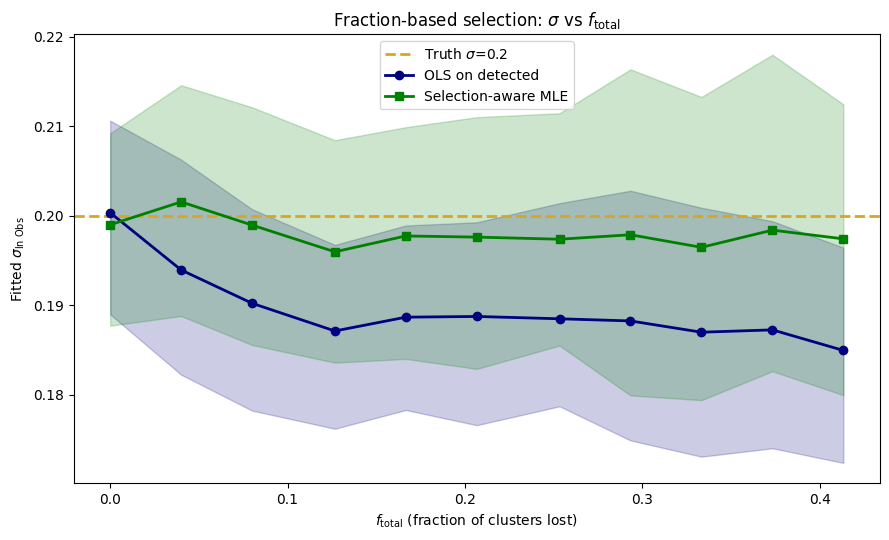

In [14]:
s_o_fm, s_o_flo, s_o_fhi = summary(results_frac['sigma_ols'])
s_s_fm, s_s_flo, s_s_fhi = summary(results_frac['sigma_sel'])
a_o_fm, a_o_flo, a_o_fhi = summary(results_frac['alpha_ols'])
a_s_fm, a_s_flo, a_s_fhi = summary(results_frac['alpha_sel'])
A_o_fm, A_o_flo, A_o_fhi = summary(results_frac['A_ols'])
A_s_fm, A_s_flo, A_s_fhi = summary(results_frac['A_sel'])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axhline(SIGMA_TRUE, color='goldenrod', ls='--', lw=2, label=fr'Truth $\sigma$={SIGMA_TRUE}')
ax.plot(f_tot_fm, s_o_fm, 'o-', color='navy', lw=2, label='OLS on detected')
ax.fill_between(f_tot_fm, s_o_flo, s_o_fhi, color='navy', alpha=0.2)
ax.plot(f_tot_fm, s_s_fm, 's-', color='green', lw=2, label='Selection-aware MLE')
ax.fill_between(f_tot_fm, s_s_flo, s_s_fhi, color='green', alpha=0.2)
ax.set_xlabel(r'$f_\mathrm{total}$ (fraction of clusters lost)')
ax.set_ylabel(r'Fitted $\sigma_{\ln\,\mathrm{Obs}}$')
ax.set_title(r'Fraction-based selection: $\sigma$ vs $f_\mathrm{total}$')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


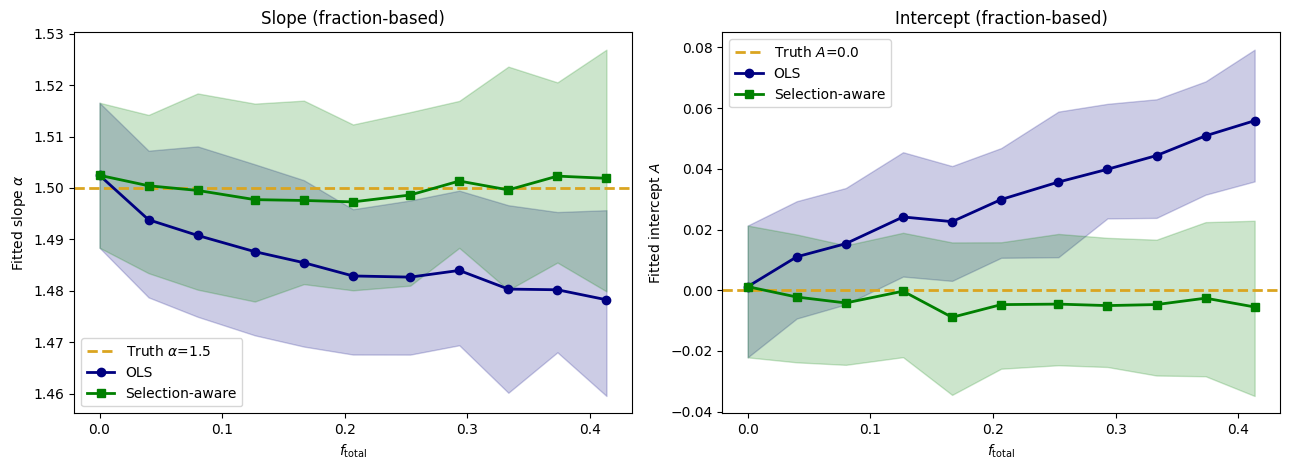

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ax1.axhline(ALPHA_TRUE, color='goldenrod', ls='--', lw=2, label=fr'Truth $\alpha$={ALPHA_TRUE}')
ax1.plot(f_tot_fm, a_o_fm, 'o-', color='navy', lw=2, label='OLS')
ax1.fill_between(f_tot_fm, a_o_flo, a_o_fhi, color='navy', alpha=0.2)
ax1.plot(f_tot_fm, a_s_fm, 's-', color='green', lw=2, label='Selection-aware')
ax1.fill_between(f_tot_fm, a_s_flo, a_s_fhi, color='green', alpha=0.2)
ax1.set_xlabel(r'$f_\mathrm{total}$')
ax1.set_ylabel(r'Fitted slope $\alpha$')
ax1.set_title('Slope (fraction-based)')
ax1.legend()

ax2.axhline(A_TRUE, color='goldenrod', ls='--', lw=2, label=fr'Truth $A$={A_TRUE}')
ax2.plot(f_tot_fm, A_o_fm, 'o-', color='navy', lw=2, label='OLS')
ax2.fill_between(f_tot_fm, A_o_flo, A_o_fhi, color='navy', alpha=0.2)
ax2.plot(f_tot_fm, A_s_fm, 's-', color='green', lw=2, label='Selection-aware')
ax2.fill_between(f_tot_fm, A_s_flo, A_s_fhi, color='green', alpha=0.2)
ax2.set_xlabel(r'$f_\mathrm{total}$')
ax2.set_ylabel(r'Fitted intercept $A$')
ax2.set_title('Intercept (fraction-based)')
ax2.legend()

plt.tight_layout()
plt.show()


### Side-by-side: threshold vs fraction

Same $\sigma$ axis, both selection styles, so the geometric contrast is direct.

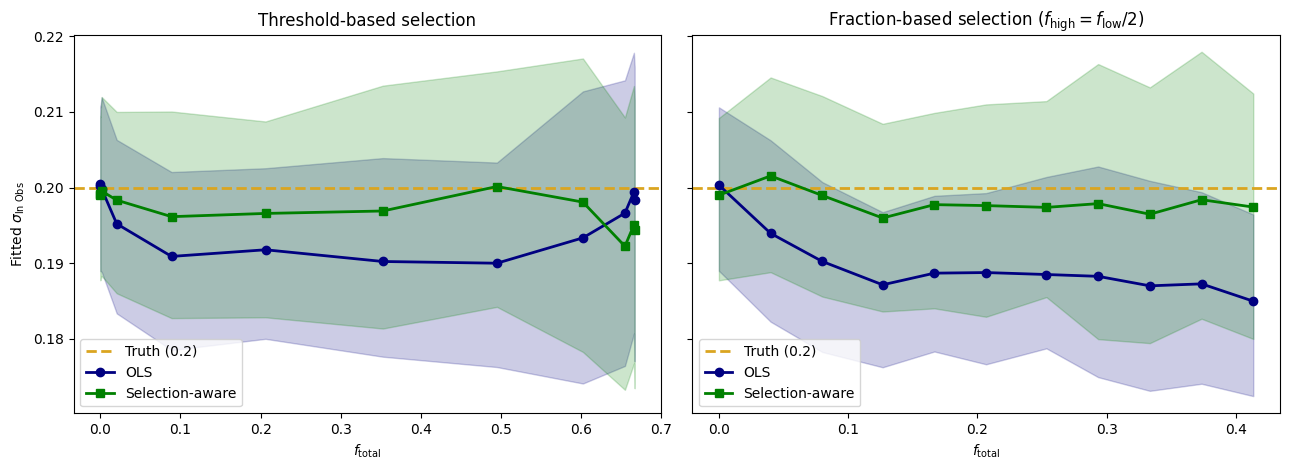

In [16]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

axL.axhline(SIGMA_TRUE, color='goldenrod', ls='--', lw=2, label=f'Truth ({SIGMA_TRUE})')
axL.plot(f_tot_m, s_o_m, 'o-', color='navy', lw=2, label='OLS')
axL.fill_between(f_tot_m, s_o_lo, s_o_hi, color='navy', alpha=0.2)
axL.plot(f_tot_m, s_s_m, 's-', color='green', lw=2, label='Selection-aware')
axL.fill_between(f_tot_m, s_s_lo, s_s_hi, color='green', alpha=0.2)
axL.set_xlabel(r'$f_\mathrm{total}$')
axL.set_ylabel(r'Fitted $\sigma_{\ln\,\mathrm{Obs}}$')
axL.set_title('Threshold-based selection')
axL.legend()

axR.axhline(SIGMA_TRUE, color='goldenrod', ls='--', lw=2, label=f'Truth ({SIGMA_TRUE})')
axR.plot(f_tot_fm, s_o_fm, 'o-', color='navy', lw=2, label='OLS')
axR.fill_between(f_tot_fm, s_o_flo, s_o_fhi, color='navy', alpha=0.2)
axR.plot(f_tot_fm, s_s_fm, 's-', color='green', lw=2, label='Selection-aware')
axR.fill_between(f_tot_fm, s_s_flo, s_s_fhi, color='green', alpha=0.2)
axR.set_xlabel(r'$f_\mathrm{total}$')
axR.set_title(r'Fraction-based selection ($f_\mathrm{high}=f_\mathrm{low}/2$)')
axR.legend()

plt.tight_layout()
plt.show()


## 11 — Null test: observable-independent random loss

The threshold-based and fraction-based scans both bias the fit because *which* clusters are lost depends on the observable — low-$y$ clusters go first. If we remove a random fraction of clusters *without* looking at their observable value, there should be no bias: a random subset of a fair sample is still a fair sample. This section confirms that expectation.

**Why bother running the null test.** Without it, someone reading the notebook could reasonably ask: "How do we know the biases in Sections 9 and 10 come from the observable-dependent nature of the selection, and not from just having fewer clusters to fit?" The random-loss scan is the answer. It removes the same total fraction of clusters — just picked uniformly at random — and shows that OLS and MLE both recover truth. That difference is what isolates the *selection effect* from the *sample-size effect*.

**Fit setup.** Under known random selection, the survival probability $P(\text{detected} \mid y, x)$ is a bin-dependent *constant* — it does not depend on $(A, \alpha, \sigma)$. In the likelihood, $-\ln P(\text{survival})$ becomes an additive constant per point and drops out of the MLE. So the "correct" selection-aware fit here is just untruncated Gaussian MLE, which we get by calling `fit_selection_aware` with $y_\mathrm{min} \to -\infty$ (implemented as a large negative number). This is a genuine null test of the whole fitting machinery.

**Real-world analogue.** Purely random loss doesn't quite happen in nature, but it's a decent proxy for *misidentification* or *catalogue-cleaning* losses — e.g. spectroscopic follow-up failed for random 15% of X-ray candidates, or a random fraction of clusters were flagged for known artefacts. What matters is that the loss cause is uncorrelated with the observable used for the fit.

In [18]:
def random_selection(y, bin_lab, f_low, f_high, rng):
    """Randomly remove f_low fraction from bin 0, f_high from bin 1.
    Selection is INDEPENDENT of the observable — this is the null test.
    """
    detected = np.ones(len(y), dtype=bool)
    for k, f in [(0, f_low), (1, f_high)]:
        idx = np.where(bin_lab == k)[0]
        if len(idx) == 0 or f <= 0:
            continue
        n_remove = int(round(f * len(idx)))
        if n_remove == 0:
            continue
        if n_remove >= len(idx):
            detected[idx] = False
            continue
        to_remove = rng.choice(idx, size=n_remove, replace=False)
        detected[to_remove] = False
    return detected

### Diagnostic: single mock under random loss

At $(f_\mathrm{low}, f_\mathrm{high}) = (30\%, 15\%)$, the same total loss as the fraction-based demo. The visual signature of random loss: red X's are scattered *throughout* the observable range within each bin, not clustered at the left. There is no vertical threshold line — that's the point.

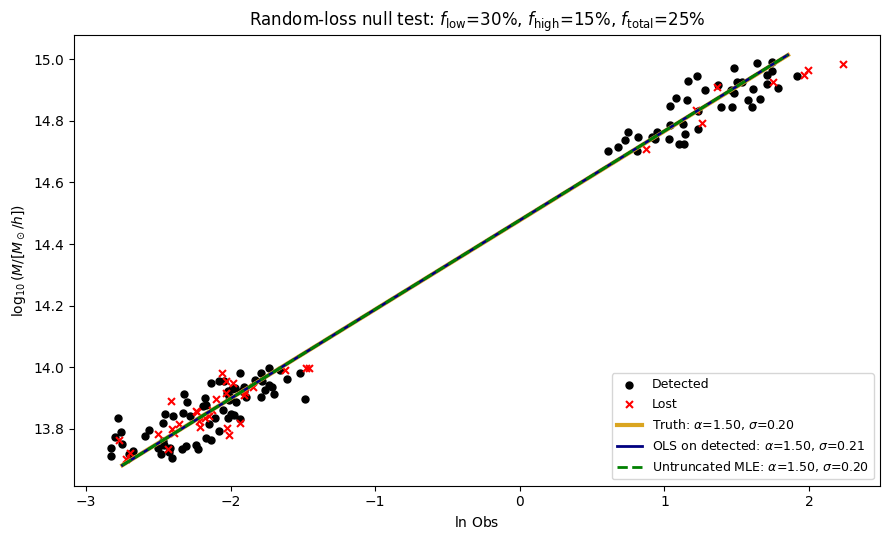

In [19]:
rng_demo3 = np.random.default_rng(23)
M, x, y, bin_lab = generate_mock(N_LOW, N_HIGH, M_EDGES_LOW, M_EDGES_HIGH, rng_demo3)

F_LOW_DEMO  = 0.30
F_HIGH_DEMO = 0.15
detected = random_selection(y, bin_lab, F_LOW_DEMO, F_HIGH_DEMO, rng_demo3)

Ao, ao, so = fit_ols(x[detected], y[detected])
# Under known random selection, no truncation — pass y_min = -infinity
As, as_, ss = fit_selection_aware(
    x[detected], y[detected], -1e6,
    init=(A_TRUE, ALPHA_TRUE, SIGMA_TRUE),
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(y[detected],  np.log10(M[detected]),  c='black', s=25, label='Detected')
ax.scatter(y[~detected], np.log10(M[~detected]), c='red', s=25, marker='x', label='Lost')

x_grid = np.linspace(x.min() - 0.05, x.max() + 0.05, 100)
logM_grid = np.log10(M_PIV * np.exp(x_grid))
ax.plot(A_TRUE + ALPHA_TRUE * x_grid, logM_grid,
        color='goldenrod', lw=3, label=fr'Truth: $\alpha$={ALPHA_TRUE:.2f}, $\sigma$={SIGMA_TRUE:.2f}')
ax.plot(Ao + ao * x_grid, logM_grid,
        color='navy', lw=2, label=fr'OLS on detected: $\alpha$={ao:.2f}, $\sigma$={so:.2f}')
ax.plot(As + as_ * x_grid, logM_grid,
        color='green', ls='--', lw=2,
        label=fr'Untruncated MLE: $\alpha$={as_:.2f}, $\sigma$={ss:.2f}')

f_tot_demo = 1 - detected.mean()
ax.set_title(fr'Random-loss null test: $f_\mathrm{{low}}$={F_LOW_DEMO:.0%}, $f_\mathrm{{high}}$={F_HIGH_DEMO:.0%}, $f_\mathrm{{total}}$={f_tot_demo:.0%}')
ax.set_xlabel(r'$\ln\,\mathrm{Obs}$')
ax.set_ylabel(r'$\log_{10}(M / [M_\odot / h])$')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Random-loss scan

Same $f_\mathrm{low}$ grid and 2:1 ratio as the fraction-based scan, so the three scans (threshold-based, fraction-based, random) all cover comparable $f_\mathrm{total}$ ranges. Expected result: all three parameter curves stay flat at truth throughout, both fits agree, within realisation bands.

In [20]:
def scan_random(f_low_grid, ratio, n_realizations, N_low, N_high,
                M_edges_low, M_edges_high,
                seed_offset=3000, min_detected=10):
    n = len(f_low_grid)
    keys = ['f_low', 'f_high', 'f_total',
            'A_ols', 'alpha_ols', 'sigma_ols',
            'A_sel', 'alpha_sel', 'sigma_sel']
    results = {k: np.full((n, n_realizations), np.nan) for k in keys}

    for i, fl in enumerate(f_low_grid):
        fh = ratio * fl
        for j in range(n_realizations):
            rng = np.random.default_rng(seed_offset + i * 1000 + j)
            M, x, y, bin_lab = generate_mock(N_low, N_high,
                                             M_edges_low, M_edges_high, rng)
            det = random_selection(y, bin_lab, fl, fh, rng)

            results['f_low'  ][i, j] = 1 - det[bin_lab == 0].mean()
            results['f_high' ][i, j] = 1 - det[bin_lab == 1].mean()
            results['f_total'][i, j] = 1 - det.mean()

            if det.sum() < min_detected:
                continue

            xd, yd = x[det], y[det]
            Ao, ao, so = fit_ols(xd, yd)
            As, as_, ss = fit_selection_aware(
                xd, yd, -1e6, init=(A_TRUE, ALPHA_TRUE, SIGMA_TRUE))

            results['A_ols'    ][i, j] = Ao
            results['alpha_ols'][i, j] = ao
            results['sigma_ols'][i, j] = so
            results['A_sel'    ][i, j] = As
            results['alpha_sel'][i, j] = as_
            results['sigma_sel'][i, j] = ss

    return results


results_rand = scan_random(
    F_LOW_GRID, RATIO_HIGH_OVER_LOW, N_REALIZATIONS,
    N_LOW, N_HIGH, M_EDGES_LOW, M_EDGES_HIGH,
    seed_offset=3000,
)
print(f"Random-loss scan complete: {len(F_LOW_GRID)} f_low values x {N_REALIZATIONS} realisations.")

Random-loss scan complete: 11 f_low values x 100 realisations.


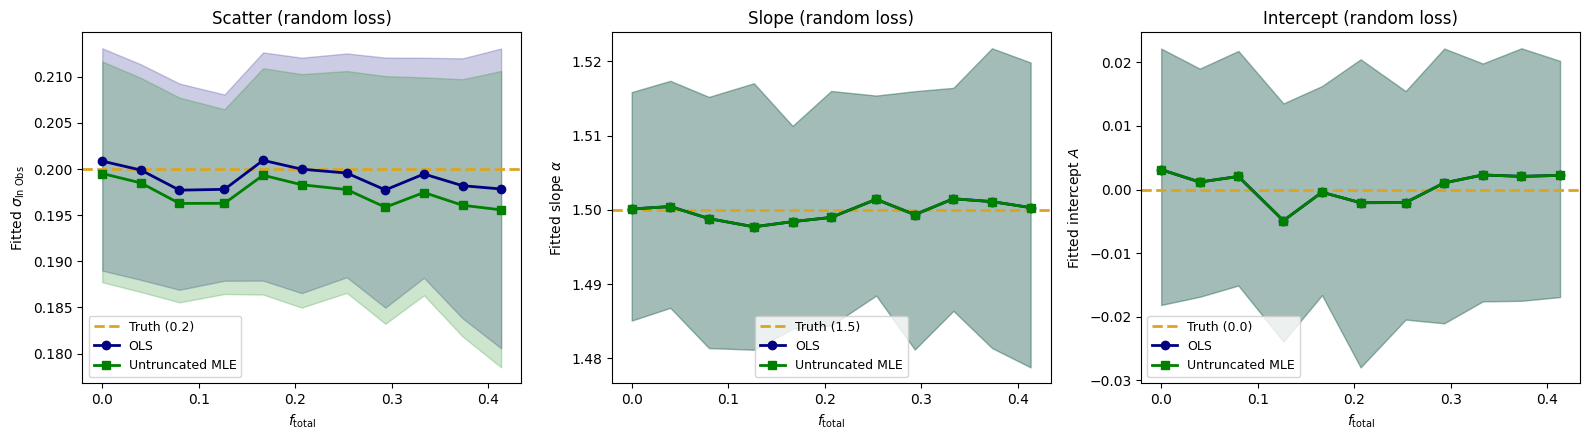

In [21]:
f_tot_rm, _, _  = summary(results_rand['f_total'])
s_o_rm, s_o_rlo, s_o_rhi = summary(results_rand['sigma_ols'])
s_s_rm, s_s_rlo, s_s_rhi = summary(results_rand['sigma_sel'])
a_o_rm, a_o_rlo, a_o_rhi = summary(results_rand['alpha_ols'])
a_s_rm, a_s_rlo, a_s_rhi = summary(results_rand['alpha_sel'])
A_o_rm, A_o_rlo, A_o_rhi = summary(results_rand['A_ols'])
A_s_rm, A_s_rlo, A_s_rhi = summary(results_rand['A_sel'])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (o_m, o_lo, o_hi), (s_m, s_lo, s_hi), truth, ylabel, title in [
    (ax1, (s_o_rm, s_o_rlo, s_o_rhi), (s_s_rm, s_s_rlo, s_s_rhi),
     SIGMA_TRUE, r'Fitted $\sigma_{\ln\,\mathrm{Obs}}$', 'Scatter'),
    (ax2, (a_o_rm, a_o_rlo, a_o_rhi), (a_s_rm, a_s_rlo, a_s_rhi),
     ALPHA_TRUE, r'Fitted slope $\alpha$', 'Slope'),
    (ax3, (A_o_rm, A_o_rlo, A_o_rhi), (A_s_rm, A_s_rlo, A_s_rhi),
     A_TRUE, r'Fitted intercept $A$', 'Intercept'),
]:
    ax.axhline(truth, color='goldenrod', ls='--', lw=2, label=f'Truth ({truth})')
    ax.plot(f_tot_rm, o_m, 'o-', color='navy', lw=2, label='OLS')
    ax.fill_between(f_tot_rm, o_lo, o_hi, color='navy', alpha=0.2)
    ax.plot(f_tot_rm, s_m, 's-', color='green', lw=2, label='Untruncated MLE')
    ax.fill_between(f_tot_rm, s_lo, s_hi, color='green', alpha=0.2)
    ax.set_xlabel(r'$f_\mathrm{total}$')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} (random loss)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11 — Takeaways and connection to `hmf_mor_forecast.py`

**Two selection geometries, two bias patterns, one solution.** Under threshold-based selection with a wide bin gap, the low bin is heavily truncated and the high bin is untouched — the slope $\alpha$ and intercept $A$ take the biggest hit while $\sigma$ is only mildly biased (the high bin anchors it). Under fraction-based selection with truncation in *both* bins, both centroids pivot upward together — the slope bias shrinks (less differential pivot) but the $\sigma$ bias grows and becomes monotonic. In both regimes, the selection-aware MLE recovers all three parameters within the realisation band by conditioning the likelihood on the (possibly bin-dependent) truncation threshold.

**Which parameter is most vulnerable depends on the geometry.** With a wide mass lever arm and asymmetric selection, worry about the *mean* relation. With balanced selection across the mass range, worry about the *scatter*. There is no universal "most-biased parameter" of a scaling relation under selection — it depends on where the cuts bite.

**Why $\sigma$ can look stable even under strong selection.** In the two-bin threshold case, the untouched high bin anchors the intrinsic width; in the endpoint region of the threshold scan, OLS $\sigma$ even *recovers* because only the untouched high bin is being fit. This isn't OLS "healing" — it's OLS fitting a subset of data that happens to be untruncated. A caution against reading $\sigma$ recovery as evidence that selection is being handled correctly.

**Connection to `hmf_mor_forecast.py`.** The selection-aware likelihood in this notebook is the per-point continuous analogue of the migration matrix in your pipeline. Both are forward-modelling operations: convolve the underlying MOR through a response function to get a prediction that lives in the same space as the observed data. In `hmf_mor_forecast.py`, the response is $P_{ij} = P(\text{observed bin } i \mid \text{true bin } j)$, applied to true counts under a Poisson likelihood on binned cluster counts. In this notebook, the response is the Gaussian survival function $P(y > y_\mathrm{min} \mid x)$, applied per detected cluster under a Gaussian likelihood on individual observables. Different observables (counts vs individual objects), different noise models (Poisson vs Gaussian), same principle: **do not fit observed data with a model that pretends the response function is trivial**.

Two features of `hmf_mor_forecast.py` extend beyond what this notebook covers:

- **Mass-dependent (observable-dependent) scatter** via `gamma_scatter`: $\sigma_{\ln O}(M) = \mathtt{frac\_scatter} \cdot (M/M_\mathrm{piv})^{\gamma}$, following the standard power-law trend used for X-ray L–M and Y–M relations ([Evrard et al. 2014](https://arxiv.org/abs/1403.1456); [Mantz et al. 2016](https://arxiv.org/abs/1606.03407)). This is the natural cousin of our fraction-based selection — the response function varies with mass. Setting `gamma_scatter = 0` recovers the constant-scatter behaviour that this notebook uses throughout.
- **Separate `P_data` (truth, frozen at setup) vs `P_model` (rebuilt each MCMC step from the sampled scatter parameters)**: lets you deliberately misspecify the scatter model and measure the resulting bias in recovered cosmology. This is the *wrong-fixed* / *free* / *marginalise* structure at the heart of your project; this notebook builds the low-level intuition for why that misspecification matters in the first place.

References for the theory: [Kelly 2007](https://arxiv.org/abs/0705.2774) §5 for the per-point selection-aware likelihood; [Mantz 2019](https://arxiv.org/abs/1902.06791) for a modern generalised treatment; the migration-matrix approach applied to cluster counts is used throughout the eROSITA cosmology chain ([Ghirardini et al. 2024](https://arxiv.org/abs/2402.08458)).

**Caveat on the fraction-based selection-aware fit.** We used the empirical $y_\mathrm{min}$ per bin (the observable value of the lowest surviving cluster) as the per-point truncation threshold. This is slightly circular — the threshold is measured from the same data being fit. In a real analysis, completeness would come from external injection–recovery tests. As $N$ per bin grows, the empirical threshold converges to the true bin-dependent completeness edge, so the bias from this circularity vanishes in the survey-scale limit.

## Suggested next steps
- **Switch to threshold on $L_X$ or $Y_{SZ}$** with realistic units — would let you compare $y_\mathrm{min}$ against literature completeness curves (e.g. from Ghirardini+24 for eRASS1).
- **Test mass-dependent scatter directly**: pipe `gamma_scatter` ≠ 0 through this notebook's data generator, then fit with a constant-scatter model. This is the per-point analogue of running `hmf_mor_forecast.py` with `gamma_scatter_data ≠ 0` and `gamma_scatter_model = 0` (the "shape-misspecified" case) — it should visibly bias the recovered $\sigma$ and $\alpha$ even under the *correct* selection.
- **Add per-point measurement error** ($y_i \to y_i + \eta_i$, $\eta \sim \mathcal{N}(0, \sigma_\mathrm{meas})$) and repeat: separates "lost the intrinsic tail" from "noisy scatter above the cut". Kelly 2007 gives the extended likelihood form.
- **Draw masses from a Tinker08 HMF** instead of uniform-in-$\log M$ — mildly amplifies the low-mass biases and matches the mass prior implicit in `hmf_mor_forecast.py`.
- **Vary the two-bin geometry** (narrower gap, more bins) to map out the regime where $\sigma$ becomes the sensitive parameter vs where $\alpha$ dominates.
- **Add a Bayesian version** with `emcee` on the truncated likelihood — corner plot of $(A, \alpha, \sigma)$ posterior under OLS-style vs correct likelihood. Directly parallels your CosmoSIS chains and would let you show marginalised covariances.sed covariances.
